In [1]:
# 1. Install the SWIG compiler directly using apt
!apt-get install -y swig

# 2. Install gymnasium with the box2d components
!pip install gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 141 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (6,823 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ub

In [2]:
import numpy as np
import gymnasium as gym
import torch
from torch import nn, optim
import torch.nn.functional as F
import random
from torch.distributions.categorical import Categorical
from collections import deque
import copy

# Plot Functions

In [3]:
import matplotlib.pyplot as plt

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def moving_std(x, w):
    return np.array([
        np.std(x[i:i+w]) if i + w <= len(x) else np.std(x[i:])
        for i in range(len(x) - w + 1)
    ])

def plot_smoothed(ax, data, window, color, title, xlabel, ylabel):
    data = np.array(data)
    if len(data) >= window:
        x      = np.arange(window - 1, len(data))
        smooth = moving_average(data, window)
        std    = moving_std(data, window)
        ax.plot(data, color=color, alpha=0.15, linewidth=0.8, label='Raw')
        ax.plot(x, smooth, color=color, linewidth=2, label=f'MA({window})')
        ax.fill_between(x, smooth - std, smooth + std, color=color, alpha=0.2, label='±1 std')
    else:
        ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_training(losses, rewards, lengths=None, window=50):
    n = 3 if lengths is not None else 2
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))

    plot_smoothed(axes[0], losses,  window, 'blue',
                   "Training Loss", "Update step", "Loss")
    plot_smoothed(axes[1], rewards, window, 'green',
                   "Reward per Episode", "Episode", "Total reward")
    if lengths is not None:
        plot_smoothed(axes[2], lengths, window, 'darkorange',
                       "Steps per Episode", "Episode", "Episode length")

    plt.suptitle("PPO Training - LunarLander", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# PPO Agent

In [4]:
class Actor(nn.Module):
    """Red que representa la política: dado un estado, devuelve
    una distribución de probabilidad sobre las acciones."""
    def __init__(self, state_size, action_size):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        # Devuelve logits; la distribución Categorical se crea fuera
        return self.net(x)


class Critic(nn.Module):
    """Red que estima el valor V(s): qué tan bueno es un estado."""
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class PPOAgent:
    def __init__(self, state_size, action_size, num_steps=128, num_envs=4):
        self.state_size  = state_size
        self.action_size = action_size
        self.num_steps   = num_steps
        self.num_envs    = num_envs
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Hiperparámetros PPO
        self.gamma        = 0.99    # factor de descuento
        self.gae_lambda   = 0.95    # lambda para GAE (Generalized Advantage Estimation)
        self.clip_eps     = 0.2     # epsilon de clipping de PPO
        self.lr           = 2.5e-4    # learning rate
        self.n_epochs     = 8       # épocas de optimización por update
        self.batch_size   = 128      # tamaño de mini-batch
        self.vf_coef      = 0.5     # coeficiente de la pérdida del crítico
        self.ent_coef     = 0.02    # coeficiente de entropía (fomenta exploración)
        self.max_grad_norm = 0.5    # clipping de gradientes

        # Redes
        self.actor  = Actor(state_size, action_size).to(self.device)
        self.critic = Critic(state_size).to(self.device)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=self.lr
        )

        # Buffer de experiencias (se llena con num_steps x num_envs transiciones)
        B = (num_steps, num_envs)
        self.obs_buf      = torch.zeros(B + (state_size,)).to(self.device)
        self.act_buf      = torch.zeros(B, dtype=torch.long).to(self.device)
        self.logp_buf     = torch.zeros(B).to(self.device)
        self.rew_buf      = torch.zeros(B).to(self.device)
        self.done_buf     = torch.zeros(B).to(self.device)
        self.val_buf      = torch.zeros(B).to(self.device)

        self.step = 0  # puntero dentro del buffer


    def act_and_store(self, states, rewards=None, terminated=None, truncated=None, final_obs=None):
        """Selecciona acciones y, si hay experiencia previa, la almacena en el buffer."""
        states_t = torch.FloatTensor(states).to(self.device)

        with torch.no_grad():
            logits = self.actor(states_t)
            dist   = Categorical(logits=logits)
            actions = dist.sample()
            logp    = dist.log_prob(actions)
            values  = self.critic(states_t)

        # Guardar observación actual, acción, log-prob y valor en el buffer
        self.obs_buf[self.step]  = states_t
        self.act_buf[self.step]  = actions
        self.logp_buf[self.step] = logp
        self.val_buf[self.step]  = values

        # Guardar recompensa y done del paso anterior (llegan en el siguiente call)
        if rewards is not None:
            dones_t = torch.FloatTensor(
                np.logical_or(terminated, truncated).astype(np.float32)
            ).to(self.device)

            # Bootstrap para episodios truncados: reemplazar obs final con obs real
            if final_obs is not None and truncated.any():
                final_t = torch.FloatTensor(final_obs).to(self.device)
                with torch.no_grad():
                    final_vals = self.critic(final_t)
                rewards = rewards.copy()
                rewards[truncated] += self.gamma * final_vals[truncated].cpu().numpy()

            prev = (self.step - 1) % self.num_steps
            self.rew_buf[prev]  = torch.FloatTensor(rewards).to(self.device)
            self.done_buf[prev] = dones_t

        self.step += 1
        return actions.cpu().numpy()


    def _compute_gae(self, next_value):
        """Calcula ventajas usando Generalized Advantage Estimation (GAE)."""
        advantages = torch.zeros_like(self.rew_buf)
        last_gae = 0.0
        for t in reversed(range(self.num_steps)):
            if t == self.num_steps - 1:
                next_val  = next_value
                next_done = torch.zeros(self.num_envs).to(self.device)
            else:
                next_val  = self.val_buf[t + 1]
                next_done = self.done_buf[t]
            delta    = self.rew_buf[t] + self.gamma * next_val * (1 - next_done) - self.val_buf[t]
            last_gae = delta + self.gamma * self.gae_lambda * (1 - next_done) * last_gae
            advantages[t] = last_gae
        returns = advantages + self.val_buf
        return advantages, returns


    def _update(self, next_states):
        """Optimiza actor y crítico con el objetivo clipeado de PPO."""
        # Valor del siguiente estado para el bootstrap de GAE
        with torch.no_grad():
            next_states_t = torch.FloatTensor(next_states).to(self.device)
            next_value    = self.critic(next_states_t)

        advantages, returns = self._compute_gae(next_value)

        # Aplanar (num_steps, num_envs) -> (num_steps * num_envs,)
        b_obs   = self.obs_buf.view(-1, self.state_size)
        b_acts  = self.act_buf.view(-1)
        b_logp  = self.logp_buf.view(-1)
        b_adv   = advantages.view(-1)
        b_ret   = returns.view(-1)

        # Normalizar ventajas
        b_adv = (b_adv - b_adv.mean()) / (b_adv.std() + 1e-8)

        total_loss = 0.0
        n_updates  = 0
        n_samples  = b_obs.shape[0]

        for _ in range(self.n_epochs):
            # Mini-batches aleatorios
            indices = torch.randperm(n_samples)
            for start in range(0, n_samples, self.batch_size):
                idx = indices[start:start + self.batch_size]

                logits   = self.actor(b_obs[idx])
                dist     = Categorical(logits=logits)
                new_logp = dist.log_prob(b_acts[idx])
                entropy  = dist.entropy().mean()
                new_val  = self.critic(b_obs[idx])

                # Ratio π_new / π_old
                ratio = torch.exp(new_logp - b_logp[idx])

                # Pérdida del actor con clipping
                adv_i     = b_adv[idx]
                loss_pi   = -torch.min(
                    ratio * adv_i,
                    torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_i
                ).mean()

                # Pérdida del crítico (MSE)
                loss_vf = F.mse_loss(new_val, b_ret[idx])

                # Pérdida total
                loss = loss_pi + self.vf_coef * loss_vf - self.ent_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()),
                    self.max_grad_norm
                )
                self.optimizer.step()

                total_loss += loss.item()
                n_updates  += 1

        # Resetear puntero del buffer
        self.step = 0
        return total_loss / n_updates


def make_env(env_id, **kwargs):
    def thunk():
        return gym.make(env_id, **kwargs)
    return thunk


def train_PPO_agent(env_name, total_timesteps, log_every=10, num_envs=4, num_steps=128, **env_kwargs):

    envs = gym.vector.SyncVectorEnv(
        [make_env(env_name, **env_kwargs) for i in range(num_envs)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP,
    )
    envs = gym.wrappers.vector.RecordEpisodeStatistics(envs)

    agent = PPOAgent(state_size=8, action_size=4, num_steps=num_steps, num_envs=num_envs)

    losses       = []
    rewards_hist = []
    lengths_hist = []
    ep_count     = 0
    global_step  = 0

    states, _ = envs.reset()
    actions   = agent.act_and_store(states)

    while global_step < total_timesteps:
        next_states, rewards, terminated, truncated, infos = envs.step(actions)
        global_step += num_envs

        # Obtener obs finales reales para bootstrap en episodios truncados
        final_obs = infos.get("final_observation", None)

        # Guardar experiencia y seleccionar próximas acciones
        actions = agent.act_and_store(
            next_states,
            rewards=rewards,
            terminated=terminated,
            truncated=truncated,
            final_obs=final_obs
        )

        # Log de episodios completados
        if "episode" in infos:
            finished   = infos["_episode"]
            ep_rewards = infos["episode"]["r"][finished]
            ep_lengths = infos["episode"]["l"][finished]
            for ep_reward, ep_length in zip(ep_rewards, ep_lengths):
                ep_reward  = float(ep_reward)
                ep_length  = int(ep_length)
                lengths_hist.append(ep_length)
                rewards_hist.append(ep_reward)
                ep_count += 1
                if ep_count % log_every == 0:
                    avg = np.mean(rewards_hist[-50:])
                    per = 100 * global_step / total_timesteps
                    print(f"Steps {global_step:>9,} ({per:4.1f}%) | Ep {ep_count:5d} | Reward: {ep_reward:8.1f} | Ep Total Steps: {ep_length:4d} | Avg(50): {avg:8.1f}")

        # Update PPO cada num_steps pasos por entorno
        if agent.step >= num_steps:
            result = agent._update(next_states)
            if result is not None:
                losses.append(result)

    envs.close()
    return agent, losses, rewards_hist, lengths_hist


agent, losses, rewards_hist, lengths_hist = train_PPO_agent(
    env_name="LunarLander-v3",
    total_timesteps=2_000_000,
    log_every=10,
    num_envs=4,
    num_steps=256,
    continuous=False,
    gravity=-10.0,
    enable_wind=True,
    wind_power=15.0,
    turbulence_power=1.5
)

Steps     1,092 ( 0.1%) | Ep    10 | Reward:   -155.2 | Ep Total Steps:   86 | Avg(50):   -263.1
Steps     1,888 ( 0.1%) | Ep    20 | Reward:   -379.2 | Ep Total Steps:  103 | Avg(50):   -240.3
Steps     2,844 ( 0.1%) | Ep    30 | Reward:   -464.8 | Ep Total Steps:   94 | Avg(50):   -260.5
Steps     3,644 ( 0.2%) | Ep    40 | Reward:   -223.3 | Ep Total Steps:   84 | Avg(50):   -261.5
Steps     4,644 ( 0.2%) | Ep    50 | Reward:   -252.7 | Ep Total Steps:   57 | Avg(50):   -266.1
Steps     5,568 ( 0.3%) | Ep    60 | Reward:    -80.5 | Ep Total Steps:   78 | Avg(50):   -262.0
Steps     6,592 ( 0.3%) | Ep    70 | Reward:   -240.3 | Ep Total Steps:  120 | Avg(50):   -265.1
Steps     7,560 ( 0.4%) | Ep    80 | Reward:   -109.7 | Ep Total Steps:   74 | Avg(50):   -246.5
Steps     8,524 ( 0.4%) | Ep    90 | Reward:   -336.6 | Ep Total Steps:  107 | Avg(50):   -243.6
Steps     9,396 ( 0.5%) | Ep   100 | Reward:   -192.5 | Ep Total Steps:  117 | Avg(50):   -222.8
Steps    10,464 ( 0.5%) | Ep  

# Evaluation

In [5]:
from gymnasium.wrappers import RecordVideo

@torch.no_grad()
def ppo_action(agent, state, deterministic=True):
    """Selecciona acción para evaluación.
    deterministic=True -> elige la acción más probable (argmax).
    deterministic=False -> samplea de la distribución.
    """
    state_t = torch.FloatTensor(state).unsqueeze(0).to(agent.device)
    logits  = agent.actor(state_t)
    if deterministic:
        action = logits.argmax(dim=-1)
    else:
        dist   = Categorical(logits=logits)
        action = dist.sample()
    return action.item()


def evaluate_agent(agent, env_name="LunarLander-v3", num_episodes=5,
                   save_dir="videos", render_video=True, deterministic=True):

    env_kwargs = dict(continuous=False, gravity=-10.0,
                      enable_wind=True, wind_power=15.0, turbulence_power=1.5)

    if render_video:
        env = gym.make(env_name, render_mode="rgb_array", **env_kwargs)
        env = RecordVideo(
            env,
            video_folder=save_dir,
            episode_trigger=lambda ep: True,
            name_prefix="lunarlander_eval",
        )
    else:
        env = gym.make(env_name, **env_kwargs)

    agent.actor.eval()

    rewards   = []
    successes = 0

    for ep in range(num_episodes):
        state, _ = env.reset()
        done  = False
        total_reward = 0
        steps = 0

        while not done:
            action = ppo_action(agent, state, deterministic=deterministic)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done  = terminated or truncated
            state = next_state
            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        if total_reward >= 200:
            successes += 1
        print(f"Episodio {ep+1:3d} | Reward: {total_reward:8.1f} | Steps: {steps:4d} | {'Logrado' if total_reward >= 200 else 'No Logrado'}")

    env.close()

    print(f"Episodios evaluados: {num_episodes}")
    print(f"Éxitos (reward>=200): {successes}/{num_episodes} ({100*successes/num_episodes:.0f}%)")
    print(f"Reward promedio: {np.mean(rewards):.1f}")
    print(f"Reward máximo:   {np.max(rewards):.1f}")
    print(f"Reward mínimo:   {np.min(rewards):.1f}")
    if render_video:
        print(f"Videos guardados en: {save_dir}/")

    return rewards, np.mean(rewards), successes / num_episodes


rewards, mean_rewards, success_rate = evaluate_agent(
    agent=agent,
    env_name="LunarLander-v3",
    num_episodes=10,
    save_dir="test_PPO",
    render_video=False
)

Episodio   1 | Reward:     26.7 | Steps:  162 | No Logrado
Episodio   2 | Reward:    282.2 | Steps:  213 | Logrado
Episodio   3 | Reward:    286.8 | Steps:  233 | Logrado
Episodio   4 | Reward:    287.7 | Steps:  222 | Logrado
Episodio   5 | Reward:    250.6 | Steps:  274 | Logrado
Episodio   6 | Reward:     -8.2 | Steps:  197 | No Logrado
Episodio   7 | Reward:    134.7 | Steps: 1000 | No Logrado
Episodio   8 | Reward:    253.1 | Steps:  324 | Logrado
Episodio   9 | Reward:    -42.2 | Steps:  123 | No Logrado
Episodio  10 | Reward:     34.3 | Steps:  147 | No Logrado
Episodios evaluados: 10
Éxitos (reward>=200): 5/10 (50%)
Reward promedio: 150.6
Reward máximo:   287.7
Reward mínimo:   -42.2


# Figures

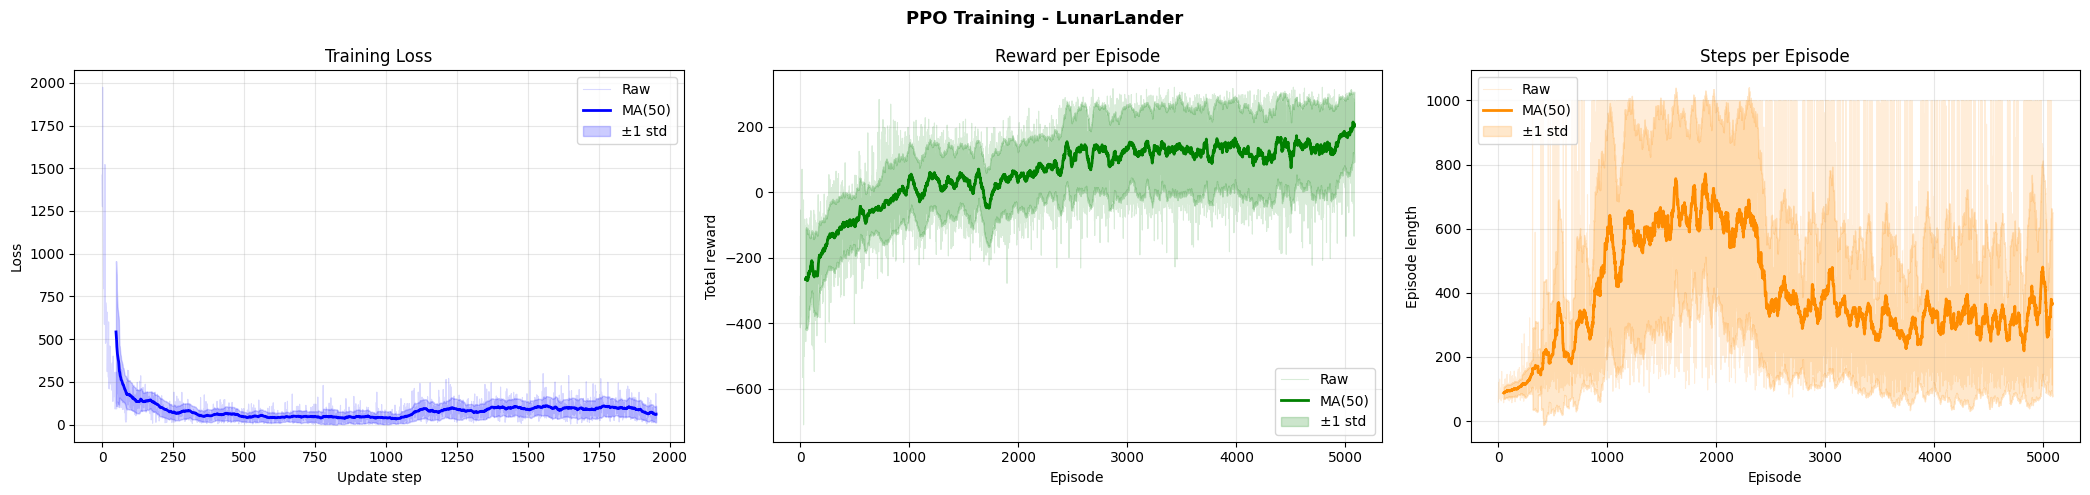

In [6]:
plot_training(losses, rewards_hist, lengths_hist, window=50)

ABLATION 1: learning rate (lr)
lr = 1e-04 → Avg(50) final: -18.9
lr = 3e-04 → Avg(50) final: -119.6
lr = 5e-04 → Avg(50) final: 79.1

ABLATION 2: n_epochs
n_epochs =  4 → Avg(50) final: 26.3
n_epochs =  8 → Avg(50) final: 43.4
n_epochs = 16 → Avg(50) final: 35.5

ABLATION 3: ent_coef
ent_coef = 0.005 → Avg(50) final: 79.0
ent_coef = 0.010 → Avg(50) final: 1.8
ent_coef = 0.020 → Avg(50) final: 38.5



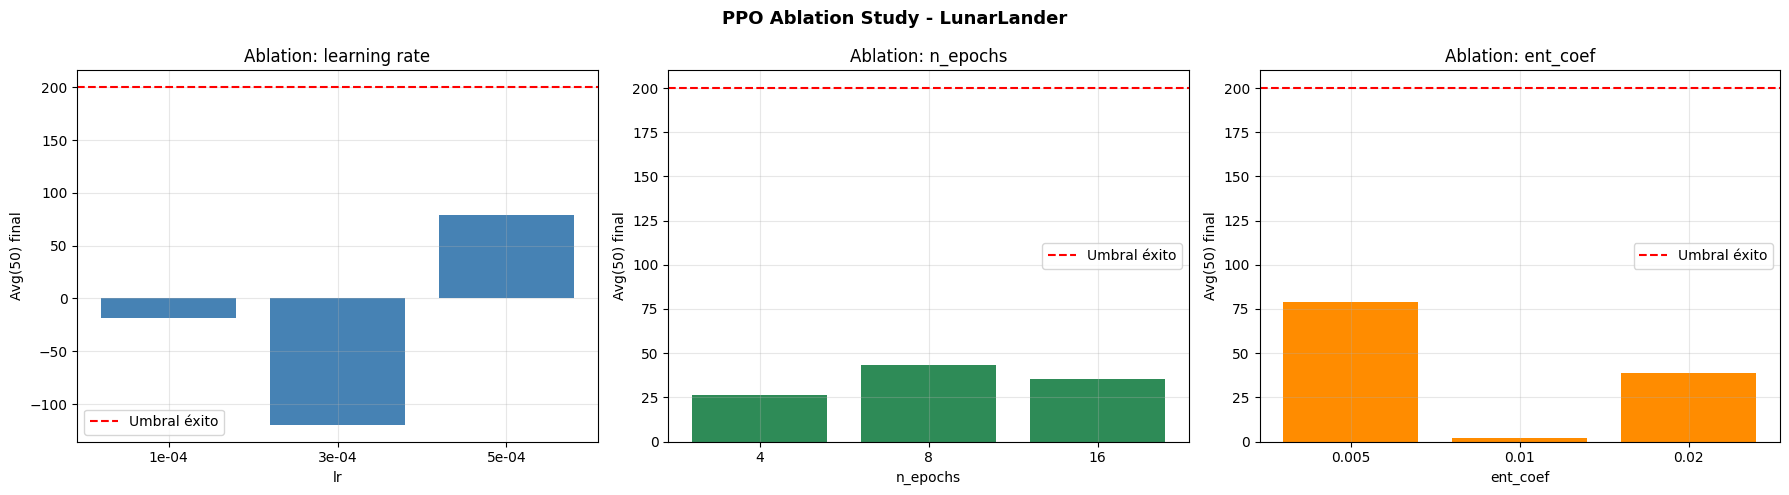


RESUMEN ABLATION PPO
----------------------------------------
learning rate:
  1e-04 → -18.9
  3e-04 → -119.6
  5e-04 → 79.1
n_epochs:
   4 → 26.3
   8 → 43.4
  16 → 35.5
ent_coef:
  0.005 → 79.0
  0.010 → 1.8
  0.020 → 38.5


In [7]:
# ablation study 

# ============================================================
# ABLATION STUDY - PPO
# Agrega estas celdas al FINAL del notebook HW3_PPO_agent.ipynb
# ============================================================

# ---- Celda 1: función de entrenamiento modificada ----

def train_PPO_agent_ablation(env_name, total_timesteps, agent_kwargs, num_envs=4, num_steps=128, **env_kwargs):
    """Igual que train_PPO_agent pero recibe kwargs para configurar el agente."""
    envs = gym.vector.SyncVectorEnv(
        [make_env(env_name, **env_kwargs) for _ in range(num_envs)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP,
    )
    envs = gym.wrappers.vector.RecordEpisodeStatistics(envs)

    agent_abl = PPOAgent(state_size=8, action_size=4, num_steps=num_steps, num_envs=num_envs)

    # Aplicar hiperparámetros personalizados
    for key, val in agent_kwargs.items():
        setattr(agent_abl, key, val)
    # Reconstruir optimizer con el lr actualizado
    agent_abl.optimizer = torch.optim.Adam(
        list(agent_abl.actor.parameters()) + list(agent_abl.critic.parameters()),
        lr=agent_abl.lr
    )

    rewards_hist = []
    global_step  = 0

    states, _ = envs.reset()
    actions   = agent_abl.act_and_store(states)

    while global_step < total_timesteps:
        next_states, rewards, terminated, truncated, infos = envs.step(actions)
        global_step += num_envs

        final_obs = infos.get("final_observation", None)
        actions   = agent_abl.act_and_store(
            next_states, rewards=rewards,
            terminated=terminated, truncated=truncated, final_obs=final_obs
        )

        if "episode" in infos:
            finished = infos["_episode"]
            for ep_reward in infos["episode"]["r"][finished]:
                rewards_hist.append(float(ep_reward))

        if agent_abl.step >= num_steps:
            agent_abl._update(next_states)

    envs.close()
    return rewards_hist


ENV_KWARGS = dict(
    continuous=False, gravity=-10.0,
    enable_wind=True, wind_power=15.0, turbulence_power=1.5
)
TIMESTEPS_ABL = 500_000  # timesteps por experimento


# ---- Celda 2: ablation sobre lr ----

print("=" * 60)
print("ABLATION 1: learning rate (lr)")
print("=" * 60)

resultados_lr = {}

for lr in [1e-4, 2.5e-4, 5e-4]:
    rewards_abl = train_PPO_agent_ablation(
        env_name="LunarLander-v3",
        total_timesteps=TIMESTEPS_ABL,
        agent_kwargs={"lr": lr},
        num_envs=4,
        num_steps=128,
        **ENV_KWARGS
    )
    avg_final = np.mean(rewards_abl[-50:]) if len(rewards_abl) >= 50 else np.mean(rewards_abl)
    resultados_lr[lr] = avg_final
    print(f"lr = {lr:.0e} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 3: ablation sobre n_epochs ----

print("=" * 60)
print("ABLATION 2: n_epochs")
print("=" * 60)

resultados_epochs = {}

for epochs in [4, 8, 16]:
    rewards_abl = train_PPO_agent_ablation(
        env_name="LunarLander-v3",
        total_timesteps=TIMESTEPS_ABL,
        agent_kwargs={"n_epochs": epochs},
        num_envs=4,
        num_steps=128,
        **ENV_KWARGS
    )
    avg_final = np.mean(rewards_abl[-50:]) if len(rewards_abl) >= 50 else np.mean(rewards_abl)
    resultados_epochs[epochs] = avg_final
    print(f"n_epochs = {epochs:2d} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 4: ablation sobre ent_coef ----

print("=" * 60)
print("ABLATION 3: ent_coef")
print("=" * 60)

resultados_ent = {}

for ent in [0.005, 0.01, 0.02]:
    rewards_abl = train_PPO_agent_ablation(
        env_name="LunarLander-v3",
        total_timesteps=TIMESTEPS_ABL,
        agent_kwargs={"ent_coef": ent},
        num_envs=4,
        num_steps=128,
        **ENV_KWARGS
    )
    avg_final = np.mean(rewards_abl[-50:]) if len(rewards_abl) >= 50 else np.mean(rewards_abl)
    resultados_ent[ent] = avg_final
    print(f"ent_coef = {ent:.3f} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 5: gráfico resumen del ablation ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning rate
axes[0].bar([f"{k:.0e}" for k in resultados_lr.keys()],
            list(resultados_lr.values()), color='steelblue')
axes[0].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[0].set_title("Ablation: learning rate")
axes[0].set_xlabel("lr")
axes[0].set_ylabel("Avg(50) final")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# n_epochs
axes[1].bar([str(k) for k in resultados_epochs.keys()],
            list(resultados_epochs.values()), color='seagreen')
axes[1].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[1].set_title("Ablation: n_epochs")
axes[1].set_xlabel("n_epochs")
axes[1].set_ylabel("Avg(50) final")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ent_coef
axes[2].bar([str(k) for k in resultados_ent.keys()],
            list(resultados_ent.values()), color='darkorange')
axes[2].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[2].set_title("Ablation: ent_coef")
axes[2].set_xlabel("ent_coef")
axes[2].set_ylabel("Avg(50) final")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("PPO Ablation Study - LunarLander", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen final
print("\nRESUMEN ABLATION PPO")
print("-" * 40)
print("learning rate:")
for k, v in resultados_lr.items():
    print(f"  {k:.0e} → {v:.1f}")
print("n_epochs:")
for k, v in resultados_epochs.items():
    print(f"  {k:2d} → {v:.1f}")
print("ent_coef:")
for k, v in resultados_ent.items():
    print(f"  {k:.3f} → {v:.1f}")